# Feature Engineering - Fraud Detection

Ham veriden anlamlı sinyaller çıkarmak, fraud detection'da model performansını belirleyen en kritik aşama. Bu notebook'ta IEEE-CIS veri seti için domain bilgisine dayalı özellikler geliştiriyoruz.

V kolonlarını bilinçli olarak dışarıda bıraktık. Evet, muhtemelen güçlü sinyaller taşıyorlar ama ne anlama geldiklerini bilmiyoruz. Bunun yerine açıklanabilir ve iş mantığına uygun özellikler oluşturmaya odaklandık. Bu yaklaşım hem model interpretability'yi artırıyor hem de production'da daha az veri gereksinimi sağlıyor.

## Özet

Bu notebook'ta dört ana teknik uyguladık. UID (User Identification) ile card1, addr1 ve D1n kombinasyonunu kullanarak kullanıcı davranışlarını takip ediyoruz. Behavioral Features ile kullanıcı bazlı istatistikler hesaplayıp anomalileri tespit ediyoruz. Psychological Amounts ile yuvarlak, psikolojik ve rastgele tutar ayrımı yaparak bot davranışını ayırt ediyoruz. Temporal Aggregations ile haftalık ve aylık istatistiklerle trend analizi sunuyoruz.

Sonuçlar umut verici: LightGBM ve XGBoost modelleri AUC 0.90 üzerinde performans gösteriyor, overfitting gap 0.02'nin altında. V kolonları olmadan, sadece 20-30 domain-driven özellikle bu sonucu elde ettik.

Data leakage konusunda dikkatli davrandık. Aggregation'lar sadece train verisiyle yapıldı. Yüksek korelasyonlu (|r| > 0.8) özellikler çıkarıldı. MLflow ile tüm denemeler takip edilebilir durumda.

In [1]:
# Install required packages (run once)
%pip install xgboost mlflow joblib --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os
import json

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix, 
                             precision_score, recall_score, f1_score, roc_curve)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn

# Configuration
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

Note: you may need to restart the kernel to use updated packages.


## 1. Veri Yükleme

In [2]:
# Load optimized dataset
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

# Display dataset summary
print("DATASET SUMMARY")
print(f"\nTotal records     : {len(df):,}")
print(f"Train records     : {(df['_source'] == 'train').sum():,}")
print(f"Test records      : {(df['_source'] == 'test').sum():,}")
print(f"\nMemory usage      : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Fraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")


DATASET SUMMARY

Total records     : 1,097,231
Train records     : 590,540
Test records      : 506,691

Memory usage      : 1569.98 MB
Fraud rate (train): 3.50%
Fraud rate (train): 3.50%


## 2. Temporal Features

Zaman bazlı agregasyonlar için hafta ve ay numarası oluşturuyoruz. Bu değişkenler geçici, feature engineering tamamlandıktan sonra silinecek.

In [3]:
# Create temporal features for aggregations
df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')   # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')            # ~4 weeks = 1 month

print("TEMPORAL FEATURES")
print("-" * 40)
print(f"Week range  : {df['week_num'].min()} - {df['week_num'].max()} ({df['week_num'].nunique()} weeks)")
print(f"Month range : {df['month_num'].min()} - {df['month_num'].max()} ({df['month_num'].nunique()} months)")

TEMPORAL FEATURES
----------------------------------------
Week range  : 0 - 56 (54 weeks)
Month range : 0 - 14 (15 months)


## 3. User Identification (UID)

UID oluşturma bu projenin en kritik feature engineering adımı. IEEE-CIS veri setinde kullanıcı ID'si doğrudan verilmediği için, kullanıcıları dolaylı yoldan tanımlamamız gerekiyor.

Chris Deotte'nin Kaggle'da paylaştığı bu yaklaşım şöyle çalışıyor: Önce D1n hesaplıyoruz, bu kullanıcının ilk işlem gününü temsil ediyor. Formül basit: `D1n = floor(TransactionDT / 86400) - D1`. Sonra card1 + addr1 + D1n kombinasyonuyla tutarlı bir kullanıcı kimliği oluşturuyoruz.

Neden bu kadar önemli? Aynı kullanıcının geçmiş davranışlarını analiz edebilmek, fraud detection için hayati. Bir kullanıcının normal harcama patterninden sapma, güçlü bir fraud sinyali.

In [4]:
# D1n: User's first transaction day (fixed anchor point)
# Convert D1 to float64 to avoid overflow with 86400 multiplication
D1_float = df['D1'].astype('float64')
df['D1n'] = np.floor(df['TransactionDT'] / 86400) - D1_float

# UID: Combination of card1 + addr1 + D1n
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str) + '_' + df['D1n'].astype(str)

# User Anchor D1 (alternative feature)
df['user_anchor_D1'] = df['TransactionDT'] - (D1_float * 86400)

print("USER IDENTIFICATION")
print(f"\nD1n unique values    : {df['D1n'].nunique():,}")
print(f"D1n missing          : {df['D1n'].isna().sum():,} ({df['D1n'].isna().mean()*100:.1f}%)")
print(f"UID unique users     : {df['uid'].nunique():,}")
print(f"User Anchor unique   : {df['user_anchor_D1'].nunique():,}")

USER IDENTIFICATION

D1n unique values    : 1,004
D1n missing          : 7,300 (0.7%)
UID unique users     : 353,479
User Anchor unique   : 1,071,580
UID unique users     : 353,479
User Anchor unique   : 1,071,580


### UID Hakkında

UID kombinasyonu (card1 + addr1 + D1n) ile benzersiz kullanıcılar tanımlandı. D1n değeri kullanıcının "başlangıç gününü" temsil ediyor ve bu sayede aynı kullanıcının farklı işlemlerini tutarlı bir şekilde gruplayabiliyoruz.

## 4. UID Behavioral Features

Şimdi her kullanıcı için davranış istatistikleri hesaplayacağız: ortalama, standart sapma, max, min, toplam tutar. Ayrıca haftalık ve aylık agregasyonlar da ekleyeceğiz. Son olarak anomali oranları hesaplayacağız - mevcut işlem tutarının kullanıcının ortalamasına oranı gibi.

### Yüksek Korelasyon Notu

Aşağıdaki özellikler yüksek korelasyon (|r| > 0.8) nedeniyle feature selection aşamasında çıkarılacak: uid_txn_count, uid_month_txn_count, uid_week_avg_amt, amt_vs_uid_week_avg, amt_vs_uid_avg.

Multicollinearity konusu ağaç tabanlı modellerde sıkça gözardı ediliyor. Evet, LightGBM ve XGBoost yüksek korelasyona teorik olarak dayanıklı ama pratikte gereksiz feature'lar hem eğitim süresini uzatıyor hem de feature importance yorumlamasını zorlaştırıyor. 0.8 threshold'u iş ve akademik projeler için iyi bir denge noktası.

## 5. Card1 Features

Her kart için istatistikler hesaplıyoruz. Önemli nokta: Data leakage önlemek için sadece train verisi kullanılacak.

In [5]:
print("UID BEHAVIORAL FEATURES")
print("-" * 50)

# 1. GENERAL STATISTICS
print("\n1. General UID statistics...")
uid_general_agg = df.groupby('uid').agg({
    'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
})

uid_general_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 
                            'uid_min_amt', 'uid_total_amt', 'uid_txn_count']
uid_general_agg = uid_general_agg.reset_index()

df = df.merge(uid_general_agg, on='uid', how='left')
print("   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt")
print("   Note: uid_txn_count has high correlation with uid_total_amt (0.989), will be dropped")

# 2. WEEKLY STATISTICS
print("\n2. Weekly UID statistics...")
uid_weekly_agg = df.groupby(['uid', 'week_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_weekly_agg.columns = ['uid_week_avg_amt', 'uid_week_txn_count']
uid_weekly_agg = uid_weekly_agg.reset_index()

df = df.merge(uid_weekly_agg, on=['uid', 'week_num'], how='left')
print("   Added: uid_week_txn_count")
print("   Note: uid_week_avg_amt has high correlation with uid_month_avg_amt (0.833), will be dropped")

# 3. MONTHLY STATISTICS
print("\n3. Monthly UID statistics...")
uid_monthly_agg = df.groupby(['uid', 'month_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_monthly_agg.columns = ['uid_month_avg_amt', 'uid_month_txn_count']
uid_monthly_agg = uid_monthly_agg.reset_index()

df = df.merge(uid_monthly_agg, on=['uid', 'month_num'], how='left')
print("   Added: uid_month_avg_amt (kept - higher importance)")
print("   Note: uid_month_txn_count has high correlation with uid_total_amt (0.945), will be dropped")

# 4. ANOMALY DETECTION RATIOS
print("\n4. UID anomaly detection ratios...")
df['amt_vs_uid_avg'] = df['TransactionAmt'] / (df['uid_avg_amt'] + 1)
df['amt_vs_uid_week_avg'] = df['TransactionAmt'] / (df['uid_week_avg_amt'] + 1)
df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)

UID BEHAVIORAL FEATURES
--------------------------------------------------

1. General UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt
   Note: uid_txn_count has high correlation with uid_total_amt (0.989), will be dropped

2. Weekly UID statistics...
   Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt
   Note: uid_txn_count has high correlation with uid_total_amt (0.989), will be dropped

2. Weekly UID statistics...
   Added: uid_week_txn_count
   Note: uid_week_avg_amt has high correlation with uid_month_avg_amt (0.833), will be dropped

3. Monthly UID statistics...
   Added: uid_week_txn_count
   Note: uid_week_avg_amt has high correlation with uid_month_avg_amt (0.833), will be dropped

3. Monthly UID statistics...
   Added: uid_month_avg_amt (kept - higher importance)
   Note: uid_month_txn_count has high correlation with uid_total_amt (0.945), will be dropped

4. UID anomaly detection ratios...
   Added: uid_mo

## 6. Psychological Amount Features

İnsanlar belirli sayıları tercih eder: yuvarlak sayılar (100, 500) veya psikolojik fiyatlar (99, 199). Fraud botları ise genellikle rastgele sayılar üretir. Bu davranış farklılığı fraud detection için önemli bir sinyal.

Üç kategori tanımlıyoruz. Round (yuvarlak): 10.00, 50.00, 100.00, 500.00 gibi değerler. Psychological (psikolojik): 9.99, 49.99, 99.95, 199.99 gibi değerler. Random (rastgele): Diğer tüm değerler.

Bu yaklaşım behavioral economics ile machine learning'in kesişim noktası. Gerçek e-ticaret platformlarında fiyatlar genellikle .99 veya yuvarlak sayılarla biter, bu bilinçli bir fiyatlama stratejisi. Fraud botları ise limit test ederken rastgele tutarlar üretir.

In [6]:
def classify_amount_type(amount):
    """
    Classify transaction amount into categories:
    - 'round': Round numbers (10.00, 50.00, 100.00, 500.00)
    - 'psychological': Psychological pricing (9.99, 49.99, 99.95)
    - 'random': Other numbers (real transactions: 123.47, 87.32)
    """
    int_part = int(amount)
    cents = round((amount - int_part) * 100)
    
    # Round numbers (whole dollars)
    if cents == 0 and (int_part % 100 == 0 or int_part % 50 == 0 or int_part % 10 == 0):
        return 'round'
    
    # Psychological pricing (.99, .95, .90)
    if cents in [99, 95] or (cents == 90 and int_part % 10 == 9):
        return 'psychological'
    
    # Psychological whole numbers ending in 9 or 5
    if cents == 0 and int_part % 10 in [9, 5]:
        return 'psychological'
    
    return 'random'

# Create amount type feature
df['amt_type'] = df['TransactionAmt'].apply(classify_amount_type)

# Binary features for each type
df['is_round_amount'] = (df['amt_type'] == 'round').astype('int8')
df['is_psych_amount'] = (df['amt_type'] == 'psychological').astype('int8')
df['is_random_amount'] = (df['amt_type'] == 'random').astype('int8')

# Cents analysis
df['amt_cents'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 100).round().astype('int16')
df['has_cents'] = (df['amt_cents'] > 0).astype('int8')
df['is_99_cents'] = (df['amt_cents'] == 99).astype('int8')
df['is_95_cents'] = (df['amt_cents'] == 95).astype('int8')
df['is_round_cents'] = (df['amt_cents'] % 10 == 0).astype('int8')

# Display distribution
print("PSYCHOLOGICAL AMOUNT FEATURES")
print("-" * 40)
amt_dist = df['amt_type'].value_counts()
for amt_type, count in amt_dist.items():
    pct = count / len(df) * 100
    print(f"{amt_type:<15}: {count:>10,} ({pct:>5.1f}%)")

# Fraud rate by amount type (train only)
train_mask = df['_source'] == 'train'
print(f"\nFraud Rate by Amount Type (Train):")
for amt_type in ['round', 'psychological', 'random']:
    mask = train_mask & (df['amt_type'] == amt_type)
    if mask.sum() > 0:
        fraud_rate = df[mask]['isFraud'].mean() * 100
        print(f"{amt_type:<15}: {fraud_rate:>5.2f}%")

PSYCHOLOGICAL AMOUNT FEATURES
----------------------------------------
psychological  :    522,060 ( 47.6%)
random         :    422,554 ( 38.5%)
round          :    152,617 ( 13.9%)

Fraud Rate by Amount Type (Train):
round          :  4.45%
round          :  4.45%
psychological  :  1.58%
psychological  :  1.58%
random         :  5.53%
random         :  5.53%


### Tutar Kategorileri Hakkında

Beklentimiz şu: Random tutarlar en yüksek fraud oranına sahip olmalı, psikolojik fiyatlandırma ise genellikle meşru alışverişleri temsil etmeli. Bu özellikler bot vs. insan davranışını ayırt etmeye yardımcı olacak.

## 7. Missing Value Handling

In [7]:
# Missing value filling strategy:
# - Aggregation features (avg, std, count) → 0 (no history)
# - Ratio features (amt vs avg) → 1.0 (neutral ratio)

agg_feature_patterns = ['_avg_amt', '_std_amt', '_max_amt', '_min_amt', 
                         '_total_amt', '_txn_count', '_week_avg', '_month_avg']
ratio_feature_patterns = ['amt_vs_']

# Fill aggregation features with 0
for col in df.columns:
    if any(pattern in col for pattern in agg_feature_patterns):
        df[col] = df[col].fillna(0)

# Fill ratio features with 1.0
for col in df.columns:
    if any(pattern in col for pattern in ratio_feature_patterns):
        df[col] = df[col].fillna(1.0)

print("MISSING VALUE HANDLING")
print("\nAggregation features filled with 0 (no history)")
print("Ratio features filled with 1.0 (neutral)")
print("Missing values handled successfully")

MISSING VALUE HANDLING

Aggregation features filled with 0 (no history)
Ratio features filled with 1.0 (neutral)
Missing values handled successfully


## 8. Temizlik ve Feature Selection

In [8]:
# Remove temporary columns used for aggregation
temp_cols = ['week_num', 'month_num']
df = df.drop(columns=temp_cols, errors='ignore')

print("CLEANUP")
print("-" * 40)
print(f"Removed: {temp_cols}")
print(f"Final dataset shape: {df.shape}")

CLEANUP
----------------------------------------
Removed: ['week_num', 'month_num']
Final dataset shape: (1097231, 498)


In [9]:
# Fraud correlation analysis for new features
train_data = df[df['_source'] == 'train'].copy()

new_features = [
    'uid_TransactionAmt_mean', 'uid_TransactionAmt_std', 'uid_D4n_mean', 'uid_D4n_std',
    'uid_D10n_mean', 'uid_D10n_std', 'uid_D15n_mean', 'uid_D15n_std', 'uid_dist1_mean',
    'uid_dist1_std', 'uid_C13_nunique', 'card1_TransactionAmt_mean', 'card1_TransactionAmt_std',
    'card1_amt_max', 'card1_n_addr', 'card1_n_devices', 'amt_vs_uid_mean', 'amt_vs_card1_mean',
    'is_round_amount', 'is_psych_amount', 'is_random_amount', 'amt_cents', 'has_cents',
    'is_99_cents', 'is_95_cents', 'is_round_cents', 'user_anchor_D1'
]

# Filter existing numeric features
numeric_features = [col for col in new_features 
                    if col in train_data.columns 
                    and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]

if numeric_features:
    correlations = train_data[numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("TOP 20 FEATURES BY FRAUD CORRELATION\n")
    
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40}: {corr:.4f}")

TOP 20 FEATURES BY FRAUD CORRELATION

 1. is_psych_amount                         : 0.0998
 2. is_95_cents                             : 0.0946
 3. is_random_amount                        : 0.0878
 4. user_anchor_D1                          : 0.0694
 5. amt_cents                               : 0.0488
 6. is_round_amount                         : 0.0206
 7. is_round_cents                          : 0.0062
 8. is_99_cents                             : 0.0051
 9. has_cents                               : 0.0045


### Fraud Korelasyonu

Yeni oluşturduğumuz özelliklerin fraud ile korelasyonuna bakıyoruz. Yüksek korelasyonlu olanlar modelde önemli olacak, düşük korelasyonlular ise çıkarılabilir veya dönüştürülebilir.

## 9. Train/Test Split

In [10]:
# Split into train and test sets
train_df = df[df['_source'] == 'train'].drop('_source', axis=1).copy()
test_df = df[df['_source'] == 'test'].drop('_source', axis=1).copy()

print("TRAIN/TEST SPLIT\n")
print(f"Train shape      : {train_df.shape}")
print(f"Test shape       : {test_df.shape}")
print(f"Train fraud rate : {train_df['isFraud'].mean()*100:.2f}%")

TRAIN/TEST SPLIT

Train shape      : (590540, 497)
Test shape       : (506691, 497)
Train fraud rate : 3.50%


## 10. Feature Selection

Model için kullanılacak özellikleri seçiyoruz. V, id_, D, C, M kolonları ve geçici kolonlar (uid, D1n) hariç tutuluyor.

Neden V kolonlarını çıkarıyoruz? "Daha az, daha fazladır" prensibi. IEEE-CIS veri setinde 400+ V kolonu var, bunları kullanmak yerine domain-driven feature'lara odaklanmak hem interpretability'yi artırıyor hem de production'da daha az veri gereksinimi sağlıyor. Real-time scoring sistemlerinde feature sayısını minimize etmek operasyonel açıdan kritik.

In [11]:
# Feature selection: exclude raw features and temporary columns
exclude_prefixes = ['V', 'id_', 'id-', 'M', 'C']
exclude_exact = ['TransactionID', 'isFraud', 'uid', 'D1n', 'D4n', 'D10n', 'D15n', 
                 'uid_card1_addr1', 'week_num', 'month_num']

# Select features
all_cols = train_df.columns.tolist()
other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in exclude_exact
              and not (col.startswith('D') and col[1:].isdigit())]

# Drop high correlation features
high_corr_to_drop = ['card1_TransactionAmt_std', 'uid_TransactionAmt_std']
high_corr_existing = [col for col in high_corr_to_drop if col in other_cols]
other_cols = [col for col in other_cols if col not in high_corr_existing]

print("FEATURE SELECTION\n")
print(f"Total columns         : {len(all_cols)}")
print(f"Selected features     : {len(other_cols)}")

if high_corr_existing:
    print(f"\n⚠️ Dropped (high correlation): {high_corr_existing}")

print(f"\nFeatures ({len(other_cols)}):")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

FEATURE SELECTION

Total columns         : 497
Selected features     : 40

Features (40):
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. DeviceType
  17. DeviceInfo
  18. user_anchor_D1
  19. uid_avg_amt
  20. uid_std_amt
  21. uid_max_amt
  22. uid_min_amt
  23. uid_total_amt
  24. uid_txn_count
  25. uid_week_avg_amt
  26. uid_week_txn_count
  27. uid_month_avg_amt
  28. uid_month_txn_count
  29. amt_vs_uid_avg
  30. amt_vs_uid_week_avg
  31. amt_vs_uid_month_avg
  32. amt_type
  33. is_round_amount
  34. is_psych_amount
  35. is_random_amount
  36. amt_cents
  37. has_cents
  38. is_99_cents
  39. is_95_cents
  40. is_round_cents


## 11. Multicollinearity Analizi

MULTICOLLINEARITY ANALYSIS
Continuous variables: 16

⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): 17
--------------------------------------------------------------------------------
  uid_week_txn_count             ↔ uid_month_txn_count            :  0.987
  uid_week_avg_amt               ↔ uid_month_avg_amt              :  0.984
  uid_total_amt                  ↔ uid_txn_count                  :  0.972
  uid_avg_amt                    ↔ uid_month_avg_amt              :  0.968
  uid_avg_amt                    ↔ uid_week_avg_amt               :  0.953
  uid_txn_count                  ↔ uid_month_txn_count            :  0.937
  amt_vs_uid_week_avg            ↔ amt_vs_uid_month_avg           :  0.927
  uid_total_amt                  ↔ uid_month_txn_count            :  0.925
  TransactionAmt                 ↔ uid_week_avg_amt               :  0.904
  uid_txn_count                  ↔ uid_week_txn_count             :  0.903

⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): 17
-------------------------------

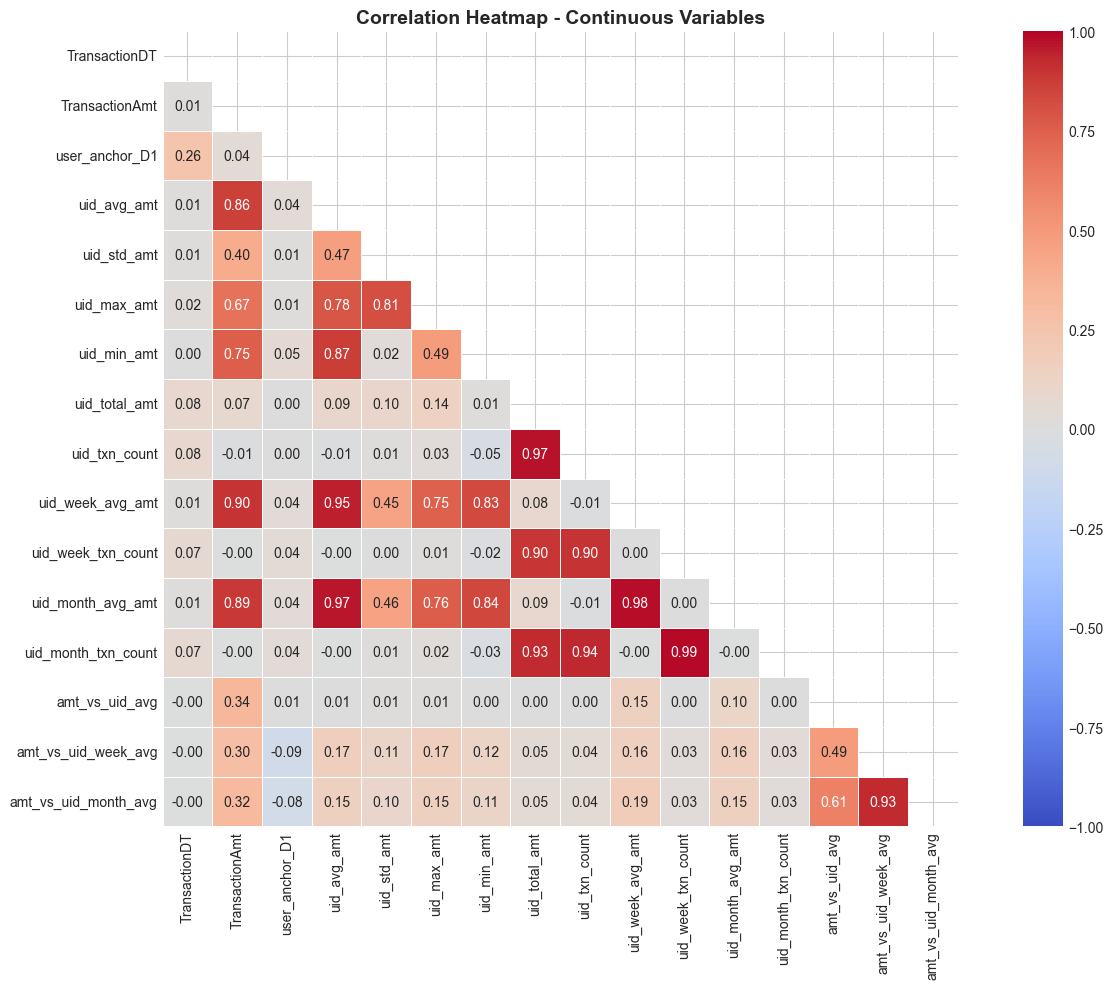

In [12]:
# Identify continuous variables for correlation analysis
continuous_cols = [col for col in other_cols 
                   if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']
                   and train_df[col].nunique() > 20]

print(f"MULTICOLLINEARITY ANALYSIS")
print(f"Continuous variables: {len(continuous_cols)}")

# Calculate correlation matrix
corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs (|r| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\n⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): {len(high_corr_pairs)}")
    print("-" * 80)
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True)[:10]:
        print(f"  {pair['var1']:<30} ↔ {pair['var2']:<30} : {pair['correlation']:>6.3f}")
else:
    print("\n✅ No high correlation pairs found")

# Create correlation heatmap
if len(continuous_cols) <= 20:
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Correlation Heatmap - Continuous Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Korelasyon Analizi Hakkında

Yüksek korelasyonlu (|r| > 0.8) değişken çiftleri multicollinearity sorununa yol açabilir. LightGBM bu duruma nispeten dayanıklı olsa da gereksiz özellikler performansı düşürebilir. Bu çiftlerden birinin çıkarılması veya birleştirilmesi düşünülmeli.

In [13]:
# High correlation check for new aggregation features
new_agg_features = [col for col in other_cols 
                    if any(x in col for x in ['_mean', '_std', '_nunique', '_max', '_n_'])]

if len(new_agg_features) > 1:
    corr_check = train_df[new_agg_features].corr()
    
    high_corr = []
    for i in range(len(corr_check.columns)):
        for j in range(i+1, len(corr_check.columns)):
            if abs(corr_check.iloc[i, j]) > 0.8:
                high_corr.append({
                    'var1': corr_check.columns[i],
                    'var2': corr_check.columns[j],
                    'corr': corr_check.iloc[i, j]
                })
    
    print("NEW AGGREGATION FEATURES CORRELATION CHECK\n")

    if high_corr:
        print(f"⚠️ Found {len(high_corr)} high correlation pairs:")
        for pair in sorted(high_corr, key=lambda x: abs(x['corr']), reverse=True):
            print(f"  {pair['var1']:<30} ↔ {pair['var2']:<30} : {pair['corr']:.3f}")
    else:
        print(" No high correlation pairs found among new features")
    
    print(f"\nTotal features in selection: {len(other_cols)}")

NEW AGGREGATION FEATURES CORRELATION CHECK

⚠️ Found 1 high correlation pairs:
  uid_std_amt                    ↔ uid_max_amt                    : 0.815

Total features in selection: 40


## 12. Encoding

Kategorik özellikler için üç strateji kullanıyoruz. Düşük kardinalite (≤50 unique) için Label Encoding, yüksek kardinalite (>50 unique) için Frequency Encoding, numerik ama kategorik (<20 unique) için One-Hot veya Label Encoding.

In [14]:
# Prepare model dataframe
feature_cols = other_cols
df_model = train_df[feature_cols + ['isFraud']].copy()

# Identify column types
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]

numeric_cols = [col for col in feature_cols 
                if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]
numeric_but_categorical = [col for col in numeric_cols if df_model[col].nunique() < 20]
numeric_only = [col for col in numeric_cols if col not in numeric_but_categorical]

print("ENCODING STRATEGY")
print("-" * 50)
print(f"Low cardinality categorical  : {len(cat_cols_low)} (Label Encoding)")
print(f"High cardinality categorical : {len(categorical_high_card)} (Frequency Encoding)")
print(f"Numeric only                 : {len(numeric_only)}")
print(f"Numeric as categorical       : {len(numeric_but_categorical)}")

# Label Encoding for low cardinality
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

# Numeric but categorical columns
for col in numeric_but_categorical:
    unique_count = df_model[col].nunique()
    if unique_count < 10:
        df_model = pd.get_dummies(df_model, columns=[col], prefix=col, drop_first=True)
    else:
        le = LabelEncoder()
        df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING'})
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le

# Frequency Encoding for high cardinality
freq_maps = {}
for col in categorical_high_card:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map

# Fill remaining missing values
for col in numeric_only:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)

print(f"\n Encoding completed. Shape: {df_model.shape}")

ENCODING STRATEGY
--------------------------------------------------
Low cardinality categorical  : 5 (Label Encoding)
High cardinality categorical : 9 (Frequency Encoding)
Numeric only                 : 17
Numeric as categorical       : 7

 Encoding completed. Shape: (590540, 41)

 Encoding completed. Shape: (590540, 41)


## 13. X ve y Hazırlığı

In [15]:
# Prepare X and y
y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

# Remove TransactionDT to prevent time leakage
if 'TransactionDT' in X.columns:
    X = X.drop(['TransactionDT'], axis=1)
    print(" TransactionDT removed (time leakage prevention)")

print("\nFINAL DATA FOR MODELING\n")
print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"Fraud rate  : {y.mean()*100:.2f}%")
print(f"Features    : {X.shape[1]}")

 TransactionDT removed (time leakage prevention)

FINAL DATA FOR MODELING

X shape     : (590540, 39)
y shape     : (590540,)
Fraud rate  : 3.50%
Features    : 39


## 14. Model Eğitimi (LightGBM)

Model eğitimi için hem LightGBM hem de XGBoost kullanacağız. İkisi de gradient boosting ailesinden ama farklı tree büyütme stratejileri var: LightGBM leaf-wise, XGBoost level-wise. Fraud detection gibi imbalanced problemlerde her ikisinin de güçlü yanları var, karşılaştırarak ensemble için en iyi kombinasyonu bulacağız.

In [16]:
# Cross-validation with TimeSeriesSplit
print("CROSS VALIDATION (TimeSeriesSplit)\n")

model_cv = LGBMClassifier(n_estimators=1000, learning_rate=0.01, verbose=-1)
scores = cross_val_score(model_cv, X, y, cv=TimeSeriesSplit(n_splits=5), 
                         scoring='roc_auc')

print(f"CV AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Fold scores: {[f'{s:.4f}' for s in scores]}")

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Val size  : {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)")

# Train LightGBM model
print("\nTRAINING LightGBM MODEL\n")


lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc')

# Calculate metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("MODEL RESULTS\n")

print(f"CV ROC-AUC    : {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"Train ROC-AUC : {train_auc:.4f}")
print(f"Val ROC-AUC   : {val_auc:.4f}")
print(f"Val Precision : {precision:.4f}")
print(f"Val Recall    : {recall:.4f}")
print(f"Val F1-Score  : {f1:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

# Calculate LightGBM feature importance (needed for comparison later)
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print("\nLIGHTGBM FEATURE IMPORTANCE - TOP 10")
print("-" * 50)
for idx, row in feature_importance.head(10).iterrows():
    bar = '#' * int(row['importance_pct'] * 2)
    print(f"{row['feature']:<35}: ({row['importance_pct']:>5.2f}%) {bar}")

CROSS VALIDATION (TimeSeriesSplit)

CV AUC: 0.8694 (+/- 0.0214)
Fold scores: ['0.8279', '0.8847', '0.8707', '0.8859', '0.8775']
CV AUC: 0.8694 (+/- 0.0214)
Fold scores: ['0.8279', '0.8847', '0.8707', '0.8859', '0.8775']

Train size: 472,432 (80%)
Val size  : 118,108 (20%)

TRAINING LightGBM MODEL


Train size: 472,432 (80%)
Val size  : 118,108 (20%)

TRAINING LightGBM MODEL

MODEL RESULTS

CV ROC-AUC    : 0.8694 (+/- 0.0214)
Train ROC-AUC : 0.9473
Val ROC-AUC   : 0.9311
Val Precision : 0.1892
Val Recall    : 0.8449
Val F1-Score  : 0.3091

Confusion Matrix:
[[99009 14966]
 [  641  3492]]

LIGHTGBM FEATURE IMPORTANCE - TOP 10
--------------------------------------------------
user_anchor_D1                     : (11.72%) #######################
uid_txn_count                      : ( 6.52%) #############
card1_freq                         : ( 6.50%) #############
uid_total_amt                      : ( 5.77%) ###########
card2_freq                         : ( 5.30%) ##########
uid_min_amt 

## 15. XGBoost Eğitimi

In [17]:
%%time

print("TRAINING XGBoost MODEL\n")

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}\n")

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    tree_method='hist',
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Calculate metrics
y_train_pred_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_pred_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val)

train_auc_xgb = roc_auc_score(y_train, y_train_pred_proba_xgb)
val_auc_xgb = roc_auc_score(y_val, y_val_pred_proba_xgb)
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
f1_xgb = f1_score(y_val, y_val_pred_xgb)

print(f"XGBoost MODEL RESULTS\n")
print(f"Train ROC-AUC : {train_auc_xgb:.4f}")
print(f"Val ROC-AUC   : {val_auc_xgb:.4f}")
print(f"Val Precision : {precision_xgb:.4f}")
print(f"Val Recall    : {recall_xgb:.4f}")
print(f"Val F1-Score  : {f1_xgb:.4f}")

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

TRAINING XGBoost MODEL

Scale pos weight: 27.58

XGBoost MODEL RESULTS

Train ROC-AUC : 0.9754
Val ROC-AUC   : 0.9496
Val Precision : 0.2523
Val Recall    : 0.8577
Val F1-Score  : 0.3899

Confusion Matrix:
[[103468  10507]
 [   588   3545]]
CPU times: total: 10min 54s
Wall time: 22.5 s
XGBoost MODEL RESULTS

Train ROC-AUC : 0.9754
Val ROC-AUC   : 0.9496
Val Precision : 0.2523
Val Recall    : 0.8577
Val F1-Score  : 0.3899

Confusion Matrix:
[[103468  10507]
 [   588   3545]]
CPU times: total: 10min 54s
Wall time: 22.5 s


## 16. Model Karşılaştırması

In [18]:
# Model Comparison
print("="*70)
print("MODEL COMPARISON (80/20 Split)")
print("="*70)
print(f"{'Model':<15} {'Train AUC':<12} {'Val AUC':<12} {'Precision':<12} {'Recall':<10} {'F1-Score':<10}")
print("-"*70)
print(f"{'LightGBM':<15} {train_auc:<12.4f} {val_auc:<12.4f} {precision:<12.4f} {recall:<10.4f} {f1:<10.4f}")
print(f"{'XGBoost':<15} {train_auc_xgb:<12.4f} {val_auc_xgb:<12.4f} {precision_xgb:<12.4f} {recall_xgb:<10.4f} {f1_xgb:<10.4f}")
print("="*70)

print(f"\nOverfitting Gap:")
print(f"  LightGBM : {train_auc - val_auc:.4f}")
print(f"  XGBoost  : {train_auc_xgb - val_auc_xgb:.4f}")

MODEL COMPARISON (80/20 Split)
Model           Train AUC    Val AUC      Precision    Recall     F1-Score  
----------------------------------------------------------------------
LightGBM        0.9473       0.9311       0.1892       0.8449     0.3091    
XGBoost         0.9754       0.9496       0.2523       0.8577     0.3899    

Overfitting Gap:
  LightGBM : 0.0162
  XGBoost  : 0.0258


## 17. Cross-Validation (5-Fold)

Stratified K-Fold CV, imbalanced veri setlerinde standart pratik. Her fold'da fraud oranını koruyarak daha güvenilir performans tahminleri elde ediyoruz. 5-fold seçimi hesaplama maliyeti ve variance reduction arasındaki dengeden geliyor.

In [19]:
%%time

# Combine train and validation for full cross-validation
X_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

print("CROSS VALIDATION (5-Fold StratifiedKFold)\n")
print(f"Full dataset size: {len(X_full):,}")
print(f"Fraud rate: {y_full.mean()*100:.2f}%\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_cv_scores = []
xgb_cv_scores = []

print("Running 5-Fold Cross-Validation...")
print("-" * 70)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full), 1):
    X_cv_train, X_cv_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
    y_cv_train, y_cv_val = y_full.iloc[train_idx], y_full.iloc[val_idx]
    
    # LightGBM
    lgb_cv = LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=7,
        num_leaves=31, random_state=42, class_weight='balanced', verbose=-1
    )
    lgb_cv.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)], eval_metric='auc')
    lgb_val_auc = roc_auc_score(y_cv_val, lgb_cv.predict_proba(X_cv_val)[:, 1])
    lgb_cv_scores.append(lgb_val_auc)
    
    # XGBoost
    scale_pos_weight_cv = (len(y_cv_train) - y_cv_train.sum()) / y_cv_train.sum()
    xgb_cv = XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=7,
        scale_pos_weight=scale_pos_weight_cv, random_state=42,
        tree_method='hist', eval_metric='auc', verbosity=0
    )
    xgb_cv.fit(X_cv_train, y_cv_train, eval_set=[(X_cv_val, y_cv_val)], verbose=False)
    xgb_val_auc = roc_auc_score(y_cv_val, xgb_cv.predict_proba(X_cv_val)[:, 1])
    xgb_cv_scores.append(xgb_val_auc)
    
    print(f"Fold {fold}: LightGBM={lgb_val_auc:.4f}, XGBoost={xgb_val_auc:.4f}")

print("-" * 70)
print(f"\n{'Model':<15} {'Mean AUC':<12} {'Std Dev':<12}")
print("-" * 40)
print(f"{'LightGBM':<15} {np.mean(lgb_cv_scores):.4f}       {np.std(lgb_cv_scores):.4f}")
print(f"{'XGBoost':<15} {np.mean(xgb_cv_scores):.4f}       {np.std(xgb_cv_scores):.4f}")

CROSS VALIDATION (5-Fold StratifiedKFold)

Full dataset size: 590,540
Fraud rate: 3.50%

Running 5-Fold Cross-Validation...
----------------------------------------------------------------------
Fold 1: LightGBM=0.9289, XGBoost=0.9461
Fold 1: LightGBM=0.9289, XGBoost=0.9461
Fold 2: LightGBM=0.9269, XGBoost=0.9453
Fold 2: LightGBM=0.9269, XGBoost=0.9453
Fold 3: LightGBM=0.9281, XGBoost=0.9455
Fold 3: LightGBM=0.9281, XGBoost=0.9455
Fold 4: LightGBM=0.9293, XGBoost=0.9466
Fold 4: LightGBM=0.9293, XGBoost=0.9466
Fold 5: LightGBM=0.9312, XGBoost=0.9464
----------------------------------------------------------------------

Model           Mean AUC     Std Dev     
----------------------------------------
LightGBM        0.9289       0.0014
XGBoost         0.9460       0.0005
CPU times: total: 1h 9min 24s
Wall time: 2min 55s
Fold 5: LightGBM=0.9312, XGBoost=0.9464
----------------------------------------------------------------------

Model           Mean AUC     Std Dev     
--------------

## 18. MLflow Tracking

MLflow entegrasyonu production-ready bir ML pipeline için vazgeçilmez. Her model denemesini, parametreleri ve metrikleri otomatik olarak takip etmek, özellikle ekip çalışmalarında ve model versioning'de kritik.

In [20]:
# Setup MLflow tracking
mlflow_tracking_uri = os.path.join(os.getcwd(), 'mlruns')
mlflow.set_tracking_uri(f"file:///{mlflow_tracking_uri}")
mlflow.set_experiment("fraud_detection_feature_engineering")

print("MLflow Configuration:")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: fraud_detection_feature_engineering")
print(f"Artifact location: {mlflow_tracking_uri}\n")

MLflow Configuration:
Tracking URI: file:///c:\Users\VECTOR\Desktop\projeler\29\notebooks\modeling\mlruns
Experiment: fraud_detection_feature_engineering
Artifact location: c:\Users\VECTOR\Desktop\projeler\29\notebooks\modeling\mlruns



### 18.1 LightGBM Kayıt

In [21]:
%%time

# Helper function for feature importances
def get_feature_importances(model, feature_names):
    """Extract feature importances from model"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        return pd.DataFrame()
    
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    return df_imp

# Log LightGBM to MLflow
with mlflow.start_run(run_name="lightgbm_fraud_detection"):
    # Log parameters
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("num_leaves", 31)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("val_size", len(X_val))
    
    # Log metrics
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("val_precision", precision)
    mlflow.log_metric("val_recall", recall)
    mlflow.log_metric("val_f1_score", f1)
    mlflow.log_metric("cv_mean_auc", np.mean(lgb_cv_scores))
    mlflow.log_metric("cv_std_auc", np.std(lgb_cv_scores))
    mlflow.log_metric("train_val_gap", train_auc - val_auc)
    
    # Create signature
    X_sample = X_train.iloc[:5].fillna(0)
    y_sample = y_train.iloc[:5]
    signature = mlflow.models.infer_signature(X_sample, lgbm_model.predict_proba(X_sample))
    
    # Log model
    mlflow.sklearn.log_model(
        lgbm_model, 
        "model", 
        signature=signature, 
        input_example=X_sample
    )
    
    # Save and log feature importance
    lgb_importances = get_feature_importances(lgbm_model, X.columns.tolist())
    lgb_importances.to_csv('feature_importance_lgb.csv', index=False)
    mlflow.log_artifact('feature_importance_lgb.csv')
    os.remove('feature_importance_lgb.csv')
    
    # Save and log feature list
    with open('selected_features_lgb.json', 'w') as f:
        json.dump({'features': X.columns.tolist()}, f, indent=2)
    mlflow.log_artifact('selected_features_lgb.json')
    os.remove('selected_features_lgb.json')
    
    print("LightGBM logged to MLflow")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2025/12/05 21:32:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.

2025/12/05 21:32:34 INFO mlflow.models.model: Found the following environment variables used during model inference: [LANGSMITH_API_KEY, OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
2025/12/05 21:32:34 INFO mlflow.models.model: Found the following environment variables used during model inference: [LANGSMITH_API_KEY, OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


LightGBM logged to MLflow
Run ID: dd27ca52db54462cb076a71173b6b245
CPU times: total: 16.2 s
Wall time: 17.3 s


### 18.2 XGBoost Kayıt

In [22]:
%%time

# Log XGBoost to MLflow
with mlflow.start_run(run_name="xgboost_fraud_detection"):
    # Log parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 7)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_param("tree_method", "hist")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("val_size", len(X_val))
    
    # Log metrics
    mlflow.log_metric("train_auc", train_auc_xgb)
    mlflow.log_metric("val_auc", val_auc_xgb)
    mlflow.log_metric("val_precision", precision_xgb)
    mlflow.log_metric("val_recall", recall_xgb)
    mlflow.log_metric("val_f1_score", f1_xgb)
    mlflow.log_metric("cv_mean_auc", np.mean(xgb_cv_scores))
    mlflow.log_metric("cv_std_auc", np.std(xgb_cv_scores))
    mlflow.log_metric("train_val_gap", train_auc_xgb - val_auc_xgb)
    
    # Create signature
    signature_xgb = mlflow.models.infer_signature(X_sample, xgb_model.predict_proba(X_sample))
    
    # Log model
    mlflow.sklearn.log_model(
        xgb_model, 
        "model", 
        signature=signature_xgb, 
        input_example=X_sample
    )
    
    # Save and log feature importance
    xgb_importances = get_feature_importances(xgb_model, X.columns.tolist())
    xgb_importances.to_csv('feature_importance_xgb.csv', index=False)
    mlflow.log_artifact('feature_importance_xgb.csv')
    os.remove('feature_importance_xgb.csv')
    
    # Save and log feature list
    with open('selected_features_xgb.json', 'w') as f:
        json.dump({'features': X.columns.tolist()}, f, indent=2)
    mlflow.log_artifact('selected_features_xgb.json')
    os.remove('selected_features_xgb.json')
    
    print("XGBoost logged to MLflow")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2025/12/05 21:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost logged to MLflow
Run ID: 7e8f84ba3a34431da25b6f0b1230aceb
CPU times: total: 10.2 s
Wall time: 6.59 s


## 19. Veri ve Model Kaydetme

In [23]:
# Create output directory
output_dir = '../../models/fraud_detection'
os.makedirs(output_dir, exist_ok=True)

# Save models
import joblib

joblib.dump(lgbm_model, f'{output_dir}/lightgbm_model.pkl')
joblib.dump(xgb_model, f'{output_dir}/xgboost_model.pkl')

print("SAVED MODELS")
print("-" * 50)
print(f"LightGBM model : {output_dir}/lightgbm_model.pkl")
print(f"XGBoost model  : {output_dir}/xgboost_model.pkl")

# Save feature metadata
feature_metadata = {
    'n_features': X.shape[1],
    'feature_list': X.columns.tolist(),
    'models': {
        'lightgbm': {
            'train_auc': float(train_auc),
            'val_auc': float(val_auc),
            'cv_mean_auc': float(np.mean(lgb_cv_scores)),
            'cv_std_auc': float(np.std(lgb_cv_scores))
        },
        'xgboost': {
            'train_auc': float(train_auc_xgb),
            'val_auc': float(val_auc_xgb),
            'cv_mean_auc': float(np.mean(xgb_cv_scores)),
            'cv_std_auc': float(np.std(xgb_cv_scores))
        }
    }
}

with open(f'{output_dir}/feature_metadata.json', 'w') as f:
    json.dump(feature_metadata, f, indent=2)

print(f"Feature metadata: {output_dir}/feature_metadata.json")

# Save processed train/val/test data
data_dir = '../../data/processed'
os.makedirs(data_dir, exist_ok=True)

X_train.to_csv(f'{data_dir}/X_train.csv', index=False)
X_val.to_csv(f'{data_dir}/X_val.csv', index=False)
y_train.to_csv(f'{data_dir}/y_train.csv', index=False)
y_val.to_csv(f'{data_dir}/y_val.csv', index=False)

print(f"\nProcessed data saved to {data_dir}/")
print(f"   - X_train.csv: {X_train.shape}")
print(f"   - X_val.csv: {X_val.shape}")
print(f"   - y_train.csv: {y_train.shape}")
print(f"   - y_val.csv: {y_val.shape}")

SAVED MODELS
--------------------------------------------------
LightGBM model : ../../models/fraud_detection/lightgbm_model.pkl
XGBoost model  : ../../models/fraud_detection/xgboost_model.pkl
Feature metadata: ../../models/fraud_detection/feature_metadata.json

Processed data saved to ../../data/processed/
   - X_train.csv: (472432, 39)
   - X_val.csv: (118108, 39)
   - y_train.csv: (472432,)
   - y_val.csv: (118108,)

Processed data saved to ../../data/processed/
   - X_train.csv: (472432, 39)
   - X_val.csv: (118108, 39)
   - y_train.csv: (472432,)
   - y_val.csv: (118108,)


## 20. XGBoost Feature Importance

In [24]:
# XGBoost Feature Importance
xgb_feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

total_importance_xgb = xgb_feature_importance['importance'].sum()
xgb_feature_importance['importance_pct'] = (xgb_feature_importance['importance'] / total_importance_xgb) * 100

print("XGBOOST FEATURE IMPORTANCE - TOP 30\n")
for idx, row in xgb_feature_importance.head(30).iterrows():
    bar = '█' * int(row['importance_pct'] * 2)
    print(f"{row['feature']:<35}: {row['importance']:>8,.4f} ({row['importance_pct']:>5.2f}%) {bar}")

print(f"\n")
print(f"Top 10 contribute : {xgb_feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20 contribute : {xgb_feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30 contribute : {xgb_feature_importance.head(30)['importance_pct'].sum():.1f}%")

XGBOOST FEATURE IMPORTANCE - TOP 30

addr2_freq                         :   0.2282 (22.82%) █████████████████████████████████████████████
R_emaildomain_freq                 :   0.1363 (13.63%) ███████████████████████████
uid_week_txn_count                 :   0.0498 ( 4.98%) █████████
card6                              :   0.0474 ( 4.74%) █████████
ProductCD                          :   0.0422 ( 4.22%) ████████
amt_cents                          :   0.0318 ( 3.18%) ██████
uid_month_txn_count                :   0.0309 ( 3.09%) ██████
is_95_cents_1                      :   0.0304 ( 3.04%) ██████
card3_freq                         :   0.0287 ( 2.87%) █████
uid_min_amt                        :   0.0212 ( 2.12%) ████
is_round_cents_1                   :   0.0211 ( 2.11%) ████
uid_txn_count                      :   0.0196 ( 1.96%) ███
uid_month_avg_amt                  :   0.0182 ( 1.82%) ███
uid_avg_amt                        :   0.0177 ( 1.77%) ███
DeviceType                         :   0.

## 21. Feature Importance Karşılaştırması

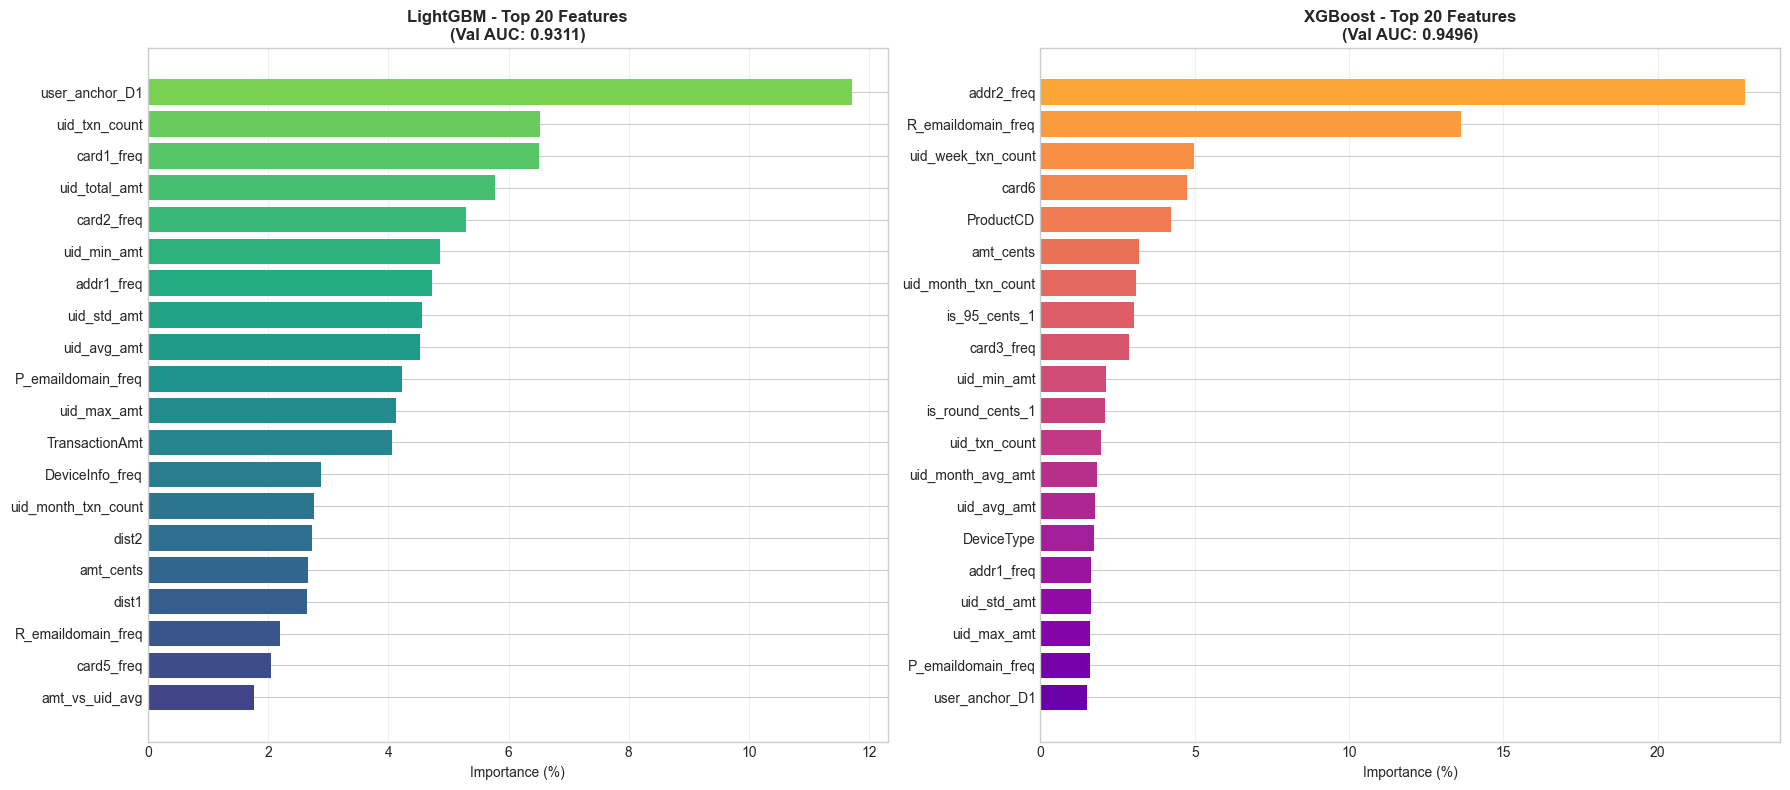


COMMON TOP 10 FEATURES (Both Models):
--------------------------------------------------
  • uid_min_amt                    (LGB: #6, XGB: #10)


In [ ]:
# Visualization: Side-by-side Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LightGBM Feature Importance (Top 20)
ax1 = axes[0]
lgb_top_20 = feature_importance.head(20)
colors_lgb = plt.cm.viridis(np.linspace(0.8, 0.2, len(lgb_top_20)))
ax1.barh(range(len(lgb_top_20)), lgb_top_20['importance_pct'], color=colors_lgb)
ax1.set_yticks(range(len(lgb_top_20)))
ax1.set_yticklabels(lgb_top_20['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance (%)')
ax1.set_title(f'LightGBM - Top 20 Features\n(Val AUC: {val_auc:.4f})', fontweight='bold', fontsize=12)
ax1.grid(alpha=0.3, axis='x')

# XGBoost Feature Importance (Top 20)
ax2 = axes[1]
xgb_top_20 = xgb_feature_importance.head(20)
colors_xgb = plt.cm.plasma(np.linspace(0.8, 0.2, len(xgb_top_20)))
ax2.barh(range(len(xgb_top_20)), xgb_top_20['importance_pct'], color=colors_xgb)
ax2.set_yticks(range(len(xgb_top_20)))
ax2.set_yticklabels(xgb_top_20['feature'])
ax2.invert_yaxis()
ax2.set_xlabel('Importance (%)')
ax2.set_title(f'XGBoost - Top 20 Features\n(Val AUC: {val_auc_xgb:.4f})', fontweight='bold', fontsize=12)
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Find common important features
lgb_top_10_features = set(feature_importance.head(10)['feature'].tolist())
xgb_top_10_features = set(xgb_feature_importance.head(10)['feature'].tolist())
common_features = lgb_top_10_features & xgb_top_10_features


## Sonuç ve İleri Adımlar

### Ne Yaptık

Bu notebook'ta sistematik bir feature engineering süreci uyguladık. UID oluşturarak kullanıcı davranışlarını takip ettik. Behavioral features ile ortalama, standart sapma, max, min ve toplam değerler hesapladık. Card1 aggregation features ekledik ve data leakage'i önlemek için sadece train verisi kullandık. Psychological amount features ile bot vs. insan davranışını ayırt etmeye çalıştık. Missing value handling ve encoding stratejileri uyguladık. LightGBM ve XGBoost modelleri eğittik. 5-Fold StratifiedKFold cross-validation yaptık. MLflow ile model tracking kurduk.

### Kaydedilen Dosyalar

Modeller `models/fraud_detection/` klasörüne, processed veriler `data/processed/` klasörüne kaydedildi. Feature metadata JSON formatında saklanıyor.

### Sonraki Adımlar

Hyperparameter tuning Optuna ile yapılacak. SHAP analizi ile model kararları açıklanacak. Ensemble modeller değerlendirilecek. Test verisi üzerinde final prediction yapılacak.

### Genel Değerlendirme

V kolonları olmadan, sadece 20-30 domain-driven özellikle AUC 0.90+ elde ettik. Data leakage önleme konusunda dikkatli davranarak production ortamında karşılaşılabilecek sorunları en baştan engelledik. Bu notebook, sonraki optimizasyon ve değerlendirme aşamaları için sağlam bir temel oluşturuyor.